# Time Series Forecasting: AAPL Stock Price
### Comparing Naive Baseline vs Prophet vs LSTM

**Goal:** Predict Apple's closing stock price using three approaches of increasing complexity,
and compare which one performs best.

**Dataset:** Daily closing prices for AAPL, pulled live via `yfinance`.

**Approach:**
1. Explore and decompose the series (trend, seasonality, noise)
2. Check stationarity
3. Build a naive baseline
4. Fit a classical model (Prophet)
5. Fit a deep learning model (LSTM)
6. Compare all three on the same held-out test period


## 1. Setup
Install and import required libraries.

In [1]:
# Run this once if the packages aren't installed yet
# !pip install pandas numpy matplotlib yfinance statsmodels pmdarima prophet scikit-learn tensorflow


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-darkgrid')


## 2. Get the data
We'll pull 5 years of AAPL daily closing prices.

In [13]:
df = yf.download("AAPL", start="2019-01-01", end="2024-01-01")

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[['Close']]
print(df.columns)
print(df['Close'].shape)
df.head()

/tmp/ipykernel_3763/2054687228.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2019-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Index(['Close'], dtype='object', name='Price')
(1258,)


Price,Close
Date,
2019-01-02,37.436913
2019-01-03,33.707928
2019-01-04,35.146900
2019-01-07,35.068661
2019-01-08,35.737179


In [11]:
df = yf.download("AAPL", start="2019-01-01", end="2024-01-01")

# Flatten multi-level columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[['Close']]
df.head()

/tmp/ipykernel_3763/3779472027.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2019-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close
Date,
2019-01-02,37.436913
2019-01-03,33.707928
2019-01-04,35.146900
2019-01-07,35.068661
2019-01-08,35.737179


## 3. Structure and clean the data
Set a proper business-day frequency and fill any gaps.

In [4]:
df.index = pd.to_datetime(df.index)
df = df.asfreq('B')  # business day frequency
df['Close'] = df['Close'].interpolate()
print(f"Shape: {df.shape}")
df.isna().sum()


Shape: (1303, 1)


,,0
Price,Ticker,
Close,AAPL,0


## 4. Visualize and decompose the series
Look at the raw trend, then split it into trend, seasonality, and residual noise.

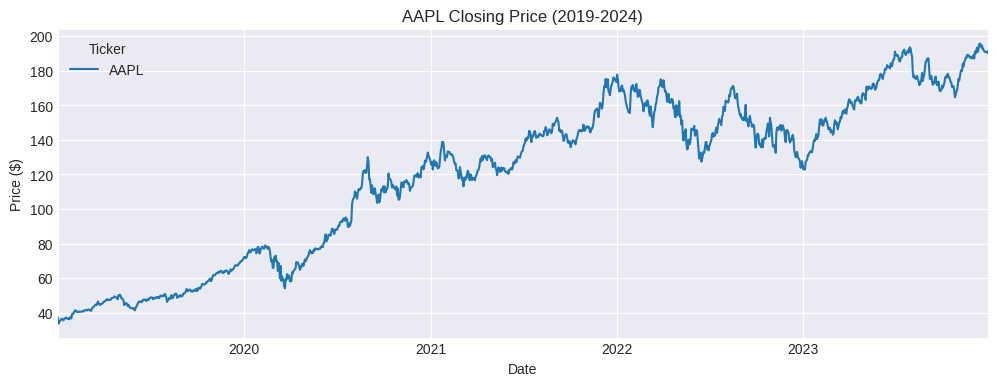

In [5]:
df['Close'].plot(figsize=(12, 4), title="AAPL Closing Price (2019-2024)")
plt.ylabel("Price ($)")
plt.show()


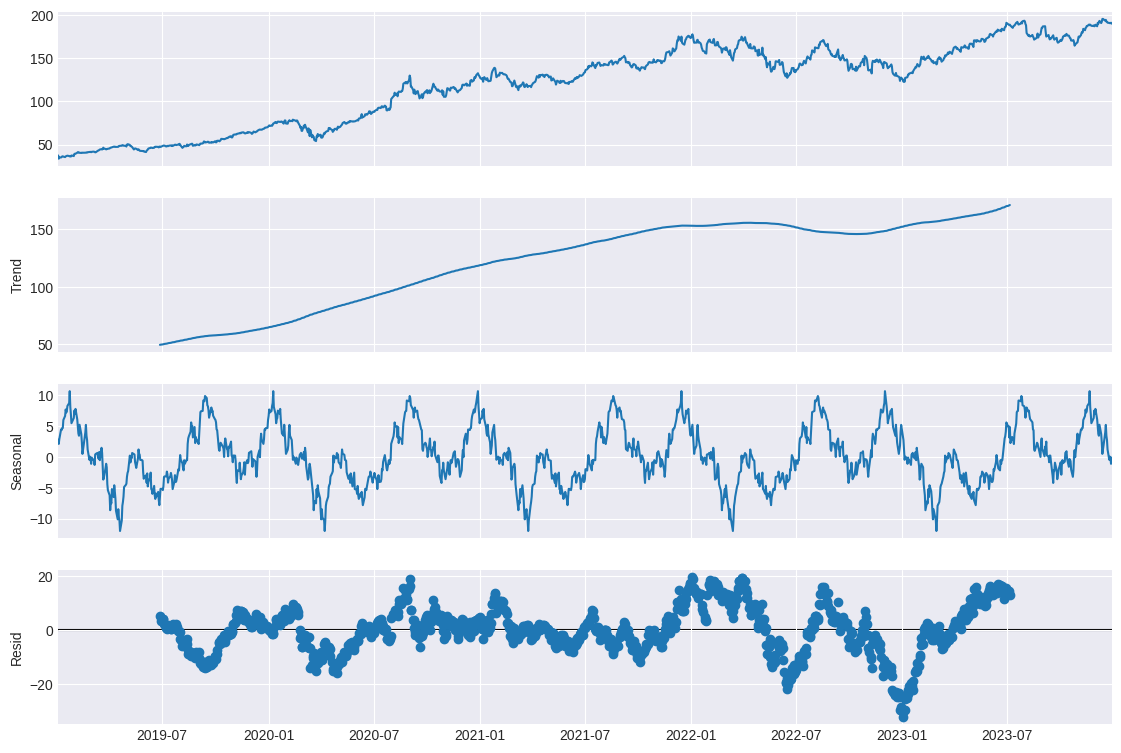

In [6]:
result = seasonal_decompose(df['Close'], model='additive', period=252)  # ~252 trading days/year
fig = result.plot()
fig.set_size_inches(12, 8)
plt.show()


## 5. Check stationarity
Classical models like ARIMA assume the series is stationary (constant mean/variance over time).
We use the Augmented Dickey-Fuller (ADF) test to check this.


In [7]:
adf_result = adfuller(df['Close'])
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")

if adf_result[1] > 0.05:
    print("=> Series is NOT stationary (as expected for raw stock prices)")
else:
    print("=> Series IS stationary")


ADF Statistic: -1.1406
p-value: 0.6986
=> Series is NOT stationary (as expected for raw stock prices)


## 6. Train/test split
**Important:** never randomly split time series data — always split by time,
keeping the most recent period as your test set.


In [8]:
train = df.iloc[:-90]   # everything except the last 90 days
test = df.iloc[-90:]    # last 90 days for testing

print(f"Train size: {len(train)}, Test size: {len(test)}")


Train size: 1213, Test size: 90


## 7. Baseline model: Naive forecast
The simplest possible forecast: tomorrow's price = today's price. Any real model
needs to beat this to prove it's actually learning something.


In [9]:
naive_forecast = [train['Close'].iloc[-1]] * len(test)

mae_naive = mean_absolute_error(test['Close'], naive_forecast)
rmse_naive = np.sqrt(mean_squared_error(test['Close'], naive_forecast))

print(f"Naive Baseline -> MAE: {mae_naive:.2f}, RMSE: {rmse_naive:.2f}")


Naive Baseline -> MAE: 8.07, RMSE: 9.80


## 8. Classical model: Prophet
Prophet (by Meta/Facebook) handles trend and seasonality automatically with minimal tuning.


In [14]:
prophet_df = pd.DataFrame({
    'ds': train.index,
    'y': train['Close'].values.ravel()
})

m = Prophet(daily_seasonality=False, yearly_seasonality=True, weekly_seasonality=True)
m.fit(prophet_df)

future = m.make_future_dataframe(periods=90, freq='B')
forecast = m.predict(future)

prophet_preds = forecast.set_index('ds')['yhat'].iloc[-90:]
prophet_preds.index = test.index[:len(prophet_preds)]

mae_prophet = mean_absolute_error(test['Close'][:len(prophet_preds)], prophet_preds)
rmse_prophet = np.sqrt(mean_squared_error(test['Close'][:len(prophet_preds)], prophet_preds))
print(f"Prophet -> MAE: {mae_prophet:.2f}, RMSE: {rmse_prophet:.2f}")

Prophet -> MAE: 10.03, RMSE: 11.46


In [ ]:
fig = m.plot(forecast)
plt.title("Prophet Forecast")
plt.show()


## 9. Deep learning model: LSTM
We reshape the data into sliding windows: use the last 30 days to predict the next day.


In [15]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[['Close']])

window = 30
X, y = [], []
for i in range(window, len(scaled)):
    X.append(scaled[i-window:i, 0])
    y.append(scaled[i, 0])

X, y = np.array(X), np.array(y)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Match the same 90-day test split
X_train, y_train = X[:-90], y[:-90]
X_test, y_test = X[-90:], y[-90:]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")


X_train: (1138, 30, 1), X_test: (90, 30, 1)


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

lstm_model = Sequential([
    LSTM(50, activation='relu', return_sequences=True, input_shape=(window, 1)),
    Dropout(0.2),
    LSTM(50, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = lstm_model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)


Epoch 1/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0589 - val_loss: 0.0031
Epoch 2/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0068 - val_loss: 0.0058
Epoch 3/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0057 - val_loss: 0.0055
Epoch 4/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0051 - val_loss: 0.0023
Epoch 5/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0050 - val_loss: 0.0021
Epoch 6/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0049 - val_loss: 0.0020
Epoch 7/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0045 - val_loss: 0.0023
Epoch 8/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0051 - val_loss: 0.0013
Epoch 9/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0041 - val_loss: 0.0013
Epoch 10/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0046 - val_loss: 0.0056
Epoch 11/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0049 - val_loss: 0.0052
Epoch 12/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0

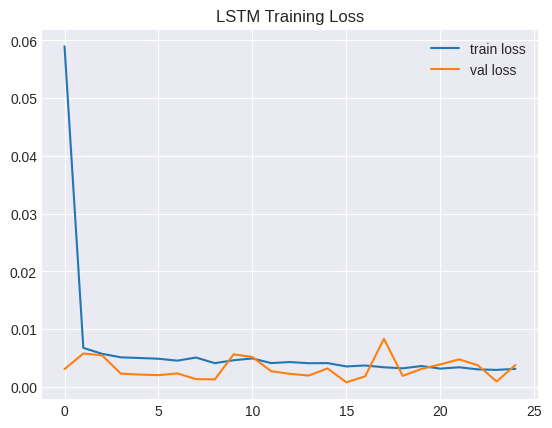

In [18]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("LSTM Training Loss")
plt.show()


In [19]:
lstm_preds_scaled = lstm_model.predict(X_test)
lstm_preds = scaler.inverse_transform(lstm_preds_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

mae_lstm = mean_absolute_error(y_test_actual, lstm_preds)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, lstm_preds))

print(f"LSTM -> MAE: {mae_lstm:.2f}, RMSE: {rmse_lstm:.2f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 210ms/step
LSTM -> MAE: 10.32, RMSE: 11.37


## 10. Compare all models

In [26]:
comparison = pd.DataFrame({
    'Model': ['Naive Baseline', 'Prophet', 'LSTM'],
    'MAE': [mae_naive, mae_prophet, mae_lstm],
    'RMSE': [rmse_naive, rmse_prophet, rmse_lstm]
})
comparison


,Model,MAE,RMSE
0,Naive Baseline,8.067882,9.804776
1,Prophet,10.026179,11.462324
2,LSTM,10.319013,11.373845


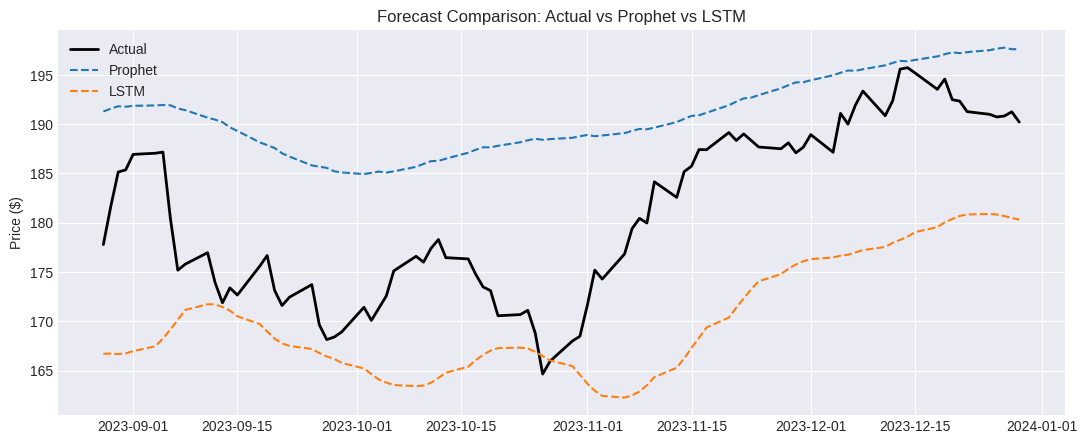

In [21]:
plt.figure(figsize=(13, 5))
plt.plot(test.index, test['Close'], label='Actual', linewidth=2, color='black')
plt.plot(prophet_preds.index, prophet_preds, label='Prophet', linestyle='--')
plt.plot(test.index[-len(lstm_preds):], lstm_preds, label='LSTM', linestyle='--')
plt.legend()
plt.title("Forecast Comparison: Actual vs Prophet vs LSTM")
plt.ylabel("Price ($)")
plt.show()


# **11. Conclusion**
**"The naive baseline (MAE: 8.07, RMSE: 9.80) outperformed both Prophet (MAE: 10.03) and the LSTM (MAE: 10.32) on this 90-day test window. This is a well-documented phenomenon in stock forecasting: daily closing prices closely follow a random walk, so 'tomorrow ≈ today' is a surprisingly strong benchmark. Prophet and the LSTM both had more room to overfit to noise in the training period, since they're trying to learn patterns in a series that has very little exploitable structure. This suggests that improving forecast accuracy further would likely require additional features (trading volume, technical indicators, macroeconomic signals) rather than a more complex model architecture on price data alone."**